# SNORLAX

SuperNova ORacle with LArge-scale model grids and eXtrapolation

### SETUP


In [1]:
using Revise 
Revise.revise()
GC.gc()

using POPSYNTH
using Printf 
using StatsBase 
using CSV 
using DataFrames 

include("/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/JuliaScripts/Plot_defs.jl")
# f_MW = POPSYNTH.read_hdf5_into_dataframe(POPSYNTH.BG_dir*"master_CORR.hdf5")
@printf("Packages and Grid loaded.\n")

Including Graphical Packages...Setting LaTeX Theme...done!
Packages and Grid loaded.


In [ ]:

hs = Dict() 
hs["0.960"] = CSV.read(POPSYNTH.SG_dir * "0.960_150.data", DataFrame, header=1, delim = ' ', ignorerepeated=true)
hs["0.980"] = CSV.read(POPSYNTH.SG_dir * "0.980_150.data", DataFrame, header=1, delim = ' ', ignorerepeated=true)
hs["1.000"] = CSV.read(POPSYNTH.SG_dir * "1.000_150.data", DataFrame, header=1, delim = ' ', ignorerepeated=true)
mu = Dict("0.960" => 1.45016, "0.980" => 1.31266, "1.000" => 1.31204, "1.200"=>0)
ρ0 = Dict("0.960" => 10^-8.4552, "0.980" => 10^-8.5158, "1.000" => 10^-8.5401, "1.200"=>0)
hs["1.200"] = CSV.read(POPSYNTH.SG_dir * "1.200_150.data", DataFrame, header=1, delim = ' ', ignorerepeated=true)


Row,model_number,star_age,star_mass,star_mdot,log_abs_mdot,log_dt,num_zones,log_total_angular_momentum,mass_conv_core,conv_mx1_top,conv_mx1_bot,conv_mx2_top,conv_mx2_bot,mx1_top,mx1_bot,mx2_top,mx2_bot,conv_mx1_top_r,conv_mx1_bot_r,conv_mx2_top_r,conv_mx2_bot_r,mx1_top_r,mx1_bot_r,mx2_top_r,mx2_bot_r,mix_type_1,mix_qtop_1,mix_type_2,mix_qtop_2,mix_type_3,mix_qtop_3,mix_type_4,mix_qtop_4,mix_type_5,mix_qtop_5,mix_type_6,mix_qtop_6,mix_type_7,mix_qtop_7,mix_type_8,mix_qtop_8,mix_type_9,mix_qtop_9,mix_type_10,mix_qtop_10,mix_relr_type_1,mix_relr_top_1,mix_relr_type_2,mix_relr_top_2,mix_relr_type_3,mix_relr_top_3,mix_relr_type_4,mix_relr_top_4,mix_relr_type_5,mix_relr_top_5,mix_relr_type_6,mix_relr_top_6,mix_relr_type_7,mix_relr_top_7,mix_relr_type_8,mix_relr_top_8,mix_relr_type_9,mix_relr_top_9,mix_relr_type_10,mix_relr_top_10,epsnuc_M_1,epsnuc_M_2,epsnuc_M_3,epsnuc_M_4,epsnuc_M_5,epsnuc_M_6,epsnuc_M_7,epsnuc_M_8,burn_type_1,burn_qtop_1,burn_type_2,burn_qtop_2,burn_type_3,burn_qtop_3,burn_type_4,burn_qtop_4,burn_type_5,burn_qtop_5,burn_type_6,burn_qtop_6,burn_type_7,burn_qtop_7,burn_type_8,burn_qtop_8,burn_type_9,burn_qtop_9,burn_type_10,burn_qtop_10,he_core_mass,he_core_radius,c_core_mass,c_core_radius,o_core_mass,o_core_radius,si_core_mass,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,1.0,0.640003,15.8489,0.0,-99.0,-0.193818,1161.0,52.0294,6.23734,0.391696,7.81279e-8,1.0,1.0,1.0,7.81279e-8,0.0,0.0,1.29482,0.00635814,4.80961,4.7681,4.86714,0.00635814,0.0,0.0,1.0,0.393551,3.0,0.469596,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,6.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,0.266644,3.0,0.291523,0.0,0.979579,1.0,0.9882,0.0,0.998266,1.0,0.999446,6.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,1.0,0.0,0.0,2.64218e34,2.94068e34,-20.0,-20.0,-20.0,-20.0,7.0,0.00733791,6.0,0.127218,5.0,0.276702,4.0,0.83702,3.0,0.921559,2.0,0.951106,1.0,0.968084,0.0,1.0,-9999.0,-1.0,-9999.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
2,2.0,1.29039,15.8489,0.0,-99.0,-0.18683,2130.0,52.0294,0.039188,0.403041,0.00247935,0.41573,0.407181,1.0,7.81279e-8,0.0,0.0,1.31333,0.220481,1.33356,1.32082,4.86815,0.00636281,0.0,0.0,1.0,0.403716,0.0,0.407181,1.0,0.416435,6.0,0.507611,1.0,0.508421,0.0,0.634264,5.0,0.734441,6.0,0.986565,5.0,0.991005,6.0,1.0,1.0,0.270002,0.0,0.271138,1.0,0.274166,6.0,0.304074,1.0,0.304343,0.0,0.348221,5.0,0.388823,6.0,0.648141,5.0,0.674401,6.0,1.0,0.0,0.0,1.27464e34,1.72319e34,2.54284e34,-20.0,-20.0,2.93059e34,7.0,0.00561472,6.0,0.124554,5.0,0.266848,4.0,0.403792,3.0,0.509026,2.0,0.831066,3.0,0.918359,2.0,0.94978,1.0,0.967961,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
3,3.0,1.97329,15.8489,0.0,-99.0,-0.165641,2212.0,52.0294,0.0265028,0.415001,0.00318352,0.417916,0.415883,1.0,7.81279e-8,0.0,0.0,1.33281,0.220627,1.33745,1.33513,4.86882,0.00636756,0.0,0.0,3.0,0.00318352,1.0,0.420824,6.0,0.481374,1.0,0.482263,0.0,0.657044,5.0,0.754824,6.0,0.99261,5.0,0.993608,6.0,1.0,-1.0,1.0,3.0,0.0453143,1.0,0.275647,6.0,0.295451,1.0,0.295744,0.0,0.356882,5.0,0.39822,6.0,0.686729,5.0,0.695584,6.0,1.0,-1.0,1.0,0.0,0.0,1.29859e34,1.70518e34,2.71029e34,-20.0,-20.0,2.92662e34,6.0,0.123666,5.0,0.266848,4.0,0.41147,3.0,0.507775,2.0,0.761056,1.0,0.830432,2.0,0.87326,3.0,0.915687,2.0,0.948548,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
4,4.0,2.69034,15.8489,0.0,-99.0,-0.144452

In [7]:
using Printf 
mu = 1.320
kB = 1.380649e-16 #erg/s
mp = 1.6605402e-24 #g
kms  = 1e5 #cm/s

T = 3420 #K
cs_id = sqrt(  kB * T/ (mu*mp) )
for vt in 0:5*kms:25*kms 
    @printf("%5.2f km/s\n", sqrt(cs_id^2 + 1/3*vt^2)/kms)
end


 4.64 km/s
 5.47 km/s
 7.41 km/s
 9.83 km/s
12.44 km/s
15.16 km/s


In [ ]:
rho_rR(r, ρ0, Hp, R) = ρ0 .* exp.( R ./ Hp .*  ( R./r .- 1) ) 
v_rR(r, ρ0, Hp, R, Mdot) = (Mdot/(4*π*ρ0)) .* 1. ./ r .^ 2 .* exp.( -R ./ Hp .* (R ./ r .- 1) )  
mdot_BondiHoyle(M, ρ, v, cs; alpha=1) = alpha * 2*π * (POPSYNTH.G*M)^2* ρ  /  (v^2 + cs^2) ^(3/2)
v_betaw(r, r0, v0; vinf = 25*kms, beta=5) =  v0 + (vinf-v0)*(1-r0/r)^beta

mp = 1.6605402e-24 #g

v_turb =  10* POPSYNTH.kms

mods = sort(collect(keys(hs)))

for key in ["1.200"]
    ix_end = length(hs[key].model_number)
    ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(hs[key],ix_end )

    M = hs[key].star_mass
    logms = log10(M[1])
    when = He_burn["0.50"]
    g = 10. ^ hs[key].log_g[when]
    R = 10. ^ hs[key].log_R[when]* Rsun
    T = 10. ^ hs[key].log_Teff[when]
    Mdot = abs(hs[key].star_mdot[when]) * Msun/ yr
    @printf("\n%5s (%5s) - %5s %5s %s %5s %5s %5s %5s\n", "M", "logM", "ZAMS", "TAMS", "iniHe", "He50", "endHe", "iniC", "endC")
    @printf("%5.2f (%5.2f) - %5d %5d %5d %5s %5d %5d %5d\n", M[1], logms, ZAMS, TAMS, ini_Heburn, He_burn["0.50"], end_Heburn, ini_Cburn, end_Cburn)
    @printf("%13s - %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f \n", "M" , M[ZAMS], M[TAMS], M[ini_Heburn], M[He_burn["0.50"]], M[end_Heburn], ini_Cburn > 0 ? M[ini_Cburn] : NaN, end_Cburn > 0 ? M[end_Cburn] : NaN)
    
    cs_id = sqrt(  kB * T/ (mu[key]*mp) ) 
    cs = sqrt(cs_id^2 + 1/3*v_turb^2)
    Hp = (g/cs^2)^(-1)

    r = collect(1:0.0001:30) .* R 
    v =   v_rR(r, ρ0[key], Hp, R, Mdot)
    ρ = rho_rR(r, ρ0[key], Hp, R)

    r_crit = R^2/(2*Hp)

    ix_sp = POPSYNTH.find_nearest(v, cs)
    v_sonic_point = v[ix_sp]
    r_sonic_point = r[ix_sp]
    ρ_sonic_point = ρ[ix_sp]
    # mdot_bhl=mdot_BondiHoyle()

    @printf("assuming v_turb = %8.2f km/s\n", v_turb/kms)
    # @printf("             ρ0 = %8.2e g/cm³\n", ρ0[key])
    # @printf("              μ = %8.2f \n", mu[key])
    @printf("              R = %8.1f Rsun \n", R/Rsun)
    # @printf("            Mdot= %8.1e Msun/yr \n", Mdot/POPSYNTH.Msun * POPSYNTH.yr)
    # @printf(" v0=Mdot/4πρ0R² = %8.2f cm/s\n", Mdot/(4*π*ρ0[key]*R^2) )
    @printf("             cs = %8.2f km/s\n", cs/kms )
    # @printf("              g = %8.2f cm/s²\n", g )
    @printf("             Hp = %8.2f Rsun\n", Hp/Rsun )
    @printf("          r(sp) = %8.2f * R\n", r_sonic_point/R )
    @printf("          r(sp) = %8.2f Rsun\n", r_sonic_point/Rsun )
    @printf("          v(sp) = %8.2f * cs\n", v_sonic_point/cs )
    @printf("          ρ(sp) = %8.2e g/cm³\n", ρ_sonic_point  )


    @printf("\n")
    for ix in ix_sp+1:1:length(r)
        v[ix] = v_betaw(r[ix], r_sonic_point, v_sonic_point)
        ρ[ix] = Mdot/(4π*v[ix]*r[ix]^2)
    end
    
    r_orbit = 5200*Rsun
    distance = r_orbit * (1-0.5)

    ix_bhl = POPSYNTH.find_nearest(r, distance)
    v_bhl = v[ix_bhl]
    r_bhl = r[ix_bhl]
    ρ_bhl = ρ[ix_bhl]
    a_omega_orb = sqrt(G*(11.8*Msun)/r_orbit)
    v2 = a_omega_orb * 9.1/(11.8+9.1)
    rel_v = sqrt(v2^2 + v_bhl^2)
    m_bhl = mdot_BondiHoyle(11.8*Msun, ρ_bhl, rel_v, cs; alpha=1) 
    @printf("          a = %8.1f Rsun\n", r_orbit/Rsun  )
    @printf("   distance = %8.1f Rsun\n", distance/Rsun  )
    @printf("     r(bhl) = %8.2f Rsun\n",  r_bhl/Rsun )
    @printf("     v(bhl) = %8.2f km/s\n",  v_bhl/kms )
    @printf("     v2     = %8.2f km/s\n",  v2/kms )
    @printf("     v_rel  = %8.2f km/s\n",  rel_v/kms )
    @printf("     ρ(bhl) = %8.2e g/cm³\n", ρ_bhl  )
    @printf("   mdot_bhl = %8.2e Msun/yr\n", m_bhl/Msun*yr  )


    
end


    M ( logM) -  ZAMS  TAMS iniHe  He50 endHe  iniC  endC
15.85 ( 1.20) -   234  1653  2529  2735  2938  3289  3438
            M - 15.85 15.27 15.17 13.56 12.09 11.95 11.93 
assuming v_turb =    10.00 km/s
              R =    823.3 Rsun 
             cs =      Inf km/s
             Hp =      Inf Rsun
          r(sp) =     1.00 * R
          r(sp) =   823.30 Rsun
          v(sp) =      NaN * cs
          ρ(sp) = 0.00e+00 g/cm³

          a =   5200.0 Rsun
   distance =   2600.0 Rsun
     r(bhl) =  2599.97 Rsun
     v(bhl) =      NaN km/s
     v2     =     9.06 km/s
     v_rel  =      NaN km/s
     ρ(bhl) =      NaN g/cm³
   mdot_bhl =      NaN Msun/yr


In [75]:
h  = CSV.read(POPSYNTH.SG_dir * "1.160_150.data", DataFrame, header=1, delim = ' ', ignorerepeated=true)

ix_end = length(h.model_number)
    ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(h,ix_end )

    M = h.star_mass
    logms = log10(M[1])
    when = He_burn["0.50"]
    g = 10. ^ h.log_g[when]
    R = 10. ^ h.log_R[when]* Rsun
    T = 10. ^ h.log_Teff[when]
    Mdot = abs(h.star_mdot[when]) * Msun/ yr
    @printf("\n%5s (%5s) - %5s %5s %s %5s %5s %5s %5s\n", "M", "logM", "ZAMS", "TAMS", "iniHe", "He50", "endHe", "iniC", "endC")
    @printf("%5.2f (%5.2f) - %5d %5d %5d %5s %5d %5d %5d\n", M[1], logms, ZAMS, TAMS, ini_Heburn, He_burn["0.50"], end_Heburn, ini_Cburn, end_Cburn)
    @printf("%13s - %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f \n", "M" , M[ZAMS], M[TAMS], M[ini_Heburn], M[He_burn["0.50"]], M[end_Heburn], ini_Cburn > 0 ? M[ini_Cburn] : NaN, end_Cburn > 0 ? M[end_Cburn] : NaN)
    
    


    M ( logM) -  ZAMS  TAMS iniHe  He50 endHe  iniC  endC
14.45 ( 1.16) -   155  1573  2442  2651  2841  3200  3342
            M - 14.45 14.00 13.93 12.76 11.79 11.67 11.65 


In [3]:
rho_rR(r, ρ0, Hp, R) = ρ0 .* exp.( R ./ Hp .*  ( R./r .- 1) ) 
v_rR(r, ρ0, Hp, R, Mdot) = (Mdot/(4*π*ρ0)) .* 1. ./ r .^ 2 .* exp.( -R ./ Hp .* (R ./ r .- 1) )  
Racc_BondiHoyle(M, v, cs) = 2*G*M/(v^2+cs^2)
mdot_BondiHoyle(M, ρ, v, cs; alpha=1) = alpha * 2*π * (G*M)^2* ρ  /  (v^2 + cs^2) ^(1.5)
v_betaw(r, r0, v0; vinf = 25*kms, beta=5) =  v0 + (vinf-v0)*(1-r0/r)^beta

mp = 1.6605402e-24 #g

rhos  = Dict("peri"=>[], "apo"=>[])
vs    = Dict("peri"=>[], "apo"=>[]) 
v2s   = Dict("peri"=>[], "apo"=>[]) 
css   = Dict("peri"=>[], "apo"=>[])
Ratms = Dict("peri"=>[], "apo"=>[])
mbhls = Dict("peri"=>[], "apo"=>[])
relvs = Dict("peri"=>[], "apo"=>[])
Raccs = Dict("peri"=>[], "apo"=>[])

v_turbs =  collect(0:.1:20)*kms

mods = sort(collect(keys(hs)))
peri_or_apo = Dict("peri"=> (1-0.5), "apo"=> (1+0.5))
r_orbit = 5200*Rsun

for v_turb  in  v_turbs

    
    key = "0.980"
    ix_end = length(hs[key].model_number)
    ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(hs[key],ix_end )

    M = hs[key].star_mass
    logms = log10(M[1])
    when = ix_end-1
    g = 10. ^ hs[key].log_g[when]
    R = 10. ^ hs[key].log_R[when]* Rsun
    T = 10. ^ hs[key].log_Teff[when]
    Mdot = abs(hs[key].star_mdot[when]) * Msun/ yr
    # @printf("\n%5s (%5s) - %5s %5s %5s %5s %5s %5s\n", "M", "logM", "ZAMS", "TAMS", "iniHe", "endHe", "iniC", "endC")
    # @printf("%5.2f (%5.2f) - %5d %5d %5d %5s %5d %5d\n", M[1], logms, ZAMS, TAMS, ini_Heburn, end_Heburn, ini_Cburn, end_Cburn)
    # @printf("%13s - %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f \n", "M" , M[ZAMS], M[TAMS], M[ini_Heburn], M[end_Heburn], ini_Cburn > 0 ? M[ini_Cburn] : NaN, end_Cburn > 0 ? M[end_Cburn] : NaN)
    
    cs_id = sqrt(  kB * T/ (mu[key]*mp) ) 
    cs = sqrt(cs_id^2 + 1/3*v_turb^2)
    Hp = (g/cs^2)^(-1)

    r = collect(1:0.0001:30) .* R 
    v =   v_rR(r, ρ0[key], Hp, R, Mdot)
    ρ = rho_rR(r, ρ0[key], Hp, R)

    r_crit = R^2/(2*Hp)

    ix_sp = POPSYNTH.find_nearest(v, cs)
    v_sonic_point = v[ix_sp]
    r_sonic_point = r[ix_sp]
    ρ_sonic_point = ρ[ix_sp]


    # mdot_bhl=mdot_BondiHoyle()

    # @printf("assuming v_turb = %8.2f km/s\n", v_turb/kms)
    # # @printf("             ρ0 = %8.2e g/cm³\n", ρ0[key])
    # # @printf("              μ = %8.2f \n", mu[key])
    # @printf("              R = %8.1f Rsun \n", R/Rsun)
    # # @printf("            Mdot= %8.1e Msun/yr \n", Mdot/POPSYNTH.Msun * POPSYNTH.yr)
    # # @printf(" v0=Mdot/4πρ0R² = %8.2f cm/s\n", Mdot/(4*π*ρ0[key]*R^2) )
    # @printf("             cs = %8.2f km/s\n", cs/kms )
    # # @printf("              g = %8.2f cm/s²\n", g )
    # @printf("             Hp = %8.2f Rsun\n", Hp/Rsun )
    # @printf("          r(sp) = %8.2f * R\n", r_sonic_point/R )
    # @printf("          r(sp) = %8.2f Rsun\n", r_sonic_point/Rsun )
    # @printf("          v(sp) = %8.2f * cs\n", v_sonic_point/cs )
    # @printf("          ρ(sp) = %8.2e g/cm³\n", ρ_sonic_point  )
    # @printf("\n")

    for ix in ix_sp+1:1:length(r)
        v[ix] = v_betaw(r[ix], r_sonic_point, v_sonic_point)
        ρ[ix] = Mdot/(4π*v[ix]*r[ix]^2)
    end
    
    e = 0.5
    for state in ["peri","apo"]

        if  abs(v_sonic_point - cs)/cs > 0.01
            push!(rhos[state],   NaN)
            push!(vs[state],     NaN)
            push!(css[state],    cs)
            push!(Ratms[state],  r_sonic_point)
            push!(mbhls[state],  NaN)
            continue
        end 

        distance = r_orbit * peri_or_apo[state]
        ix_bhl = POPSYNTH.find_nearest(r, distance)
        v_bhl = v[ix_bhl]
        r_bhl = r[ix_bhl]
        ρ_bhl = ρ[ix_bhl]
        a_omega_orb = sqrt(G*(11.8*Msun)/r_orbit)
        v2 = a_omega_orb * (state == "peri" ? (1+e)/(1-e) : (1-e)/(1+e))
        rel_v = sqrt(v2^2 + v_bhl^2)
        m_bhl = mdot_BondiHoyle(11.8*Msun, ρ_bhl, rel_v, cs; alpha=1) 
        Racc = Racc_BondiHoyle(11.8*Msun, rel_v, cs)
        # @printf("          a = %8.1f Rsun\n", r_orbit/Rsun  )
        # @printf("   distance = %8.1f Rsun\n", distance/Rsun  )
        # @printf("     r(bhl) = %8.2f Rsun\n",  r_bhl/Rsun )
        # @printf("     v(bhl) = %8.2f km/s\n",  v_bhl/kms )
        # @printf("     v2     = %8.2f km/s\n",  v2/kms )
        # @printf("     v_rel  = %8.2f km/s\n",  rel_v/kms )
        # @printf("     ρ(bhl) = %8.2e g/cm³\n", ρ_bhl  )
        # @printf("   mdot_bhl = %8.2e Msun/yr\n", m_bhl/Msun*yr  )
        # @printf(" Racc/r  = %8.2e - ", Racc/distance)
        push!(Raccs[state], Racc)
        push!(relvs[state], rel_v)
        push!(rhos[state], ρ_bhl)
        push!(v2s[state], v2)
        push!(vs[state], v_bhl)
        push!(css[state], cs)
        push!(Ratms[state], r_sonic_point)
        push!(mbhls[state], m_bhl)

    end
    # @printf("\n")
end

# for i in range(1,length(v_turbs))
#     @printf("vt=%5.1f,  R %7.1f - v_w %5.1f  cs %5.1f sqsum(vw,cs,v2)=%5.1f - ρ %5.1e  => mbhls = %5.1e\n", v_turbs[i]/kms,  Ratms[i]/Rsun, vs[i]/kms, css[i]/kms, sqrt(vs[i]^2+css[i]^2+v2s^2)/km,  rhos[i], mbhls[i]/Msun*yr)
# end

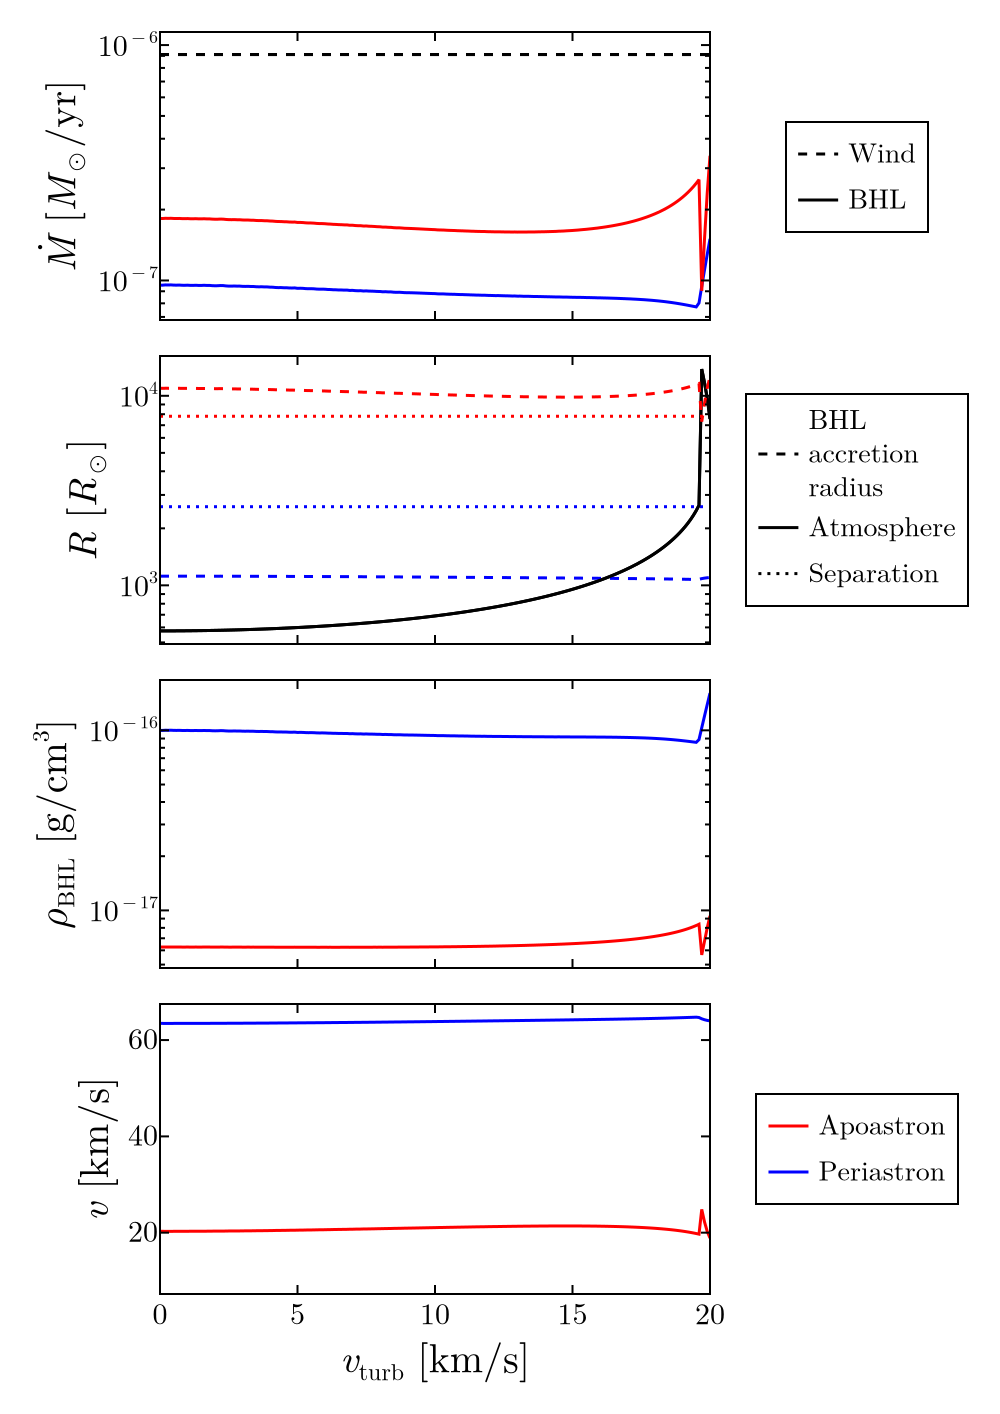

In [72]:
FIGURE = Figure(size=(500,sqrt(2)*500))
ax0 = plot_settings(FIGURE[0,1], title = "", xlabelvisible=false, xticklabelsvisible=false,
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]", yscale=log10,
                ylabel=L"\dot{M} \ [M_\odot/\mathrm{yr}]")
ax1 = plot_settings(FIGURE[1,1], title = "", xlabelvisible=false, xticklabelsvisible=false,
                ylabel=L"R \ [R_\odot]",
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]", yscale=log10)
ax2 = plot_settings(FIGURE[2,1], title = "", xlabelvisible=false, xticklabelsvisible=false,
                ylabel=L"ρ_\mathrm{BHL} \ [\mathrm{g}/\mathrm{cm}^3]",
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]", yscale=log10)
ax3 = plot_settings(FIGURE[3,1], title = "", 
                ylabel=L"v \ [\mathrm{km}/\mathrm{s}]",
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]")

peri_or_apo_col = Dict("peri"=>:blue, "apo"=>:red)
for state in ["peri", "apo"]
    lines!(ax0, v_turbs/kms, mbhls[state]/Msun*yr, color = peri_or_apo_col[state])
    lines!(ax0, v_turbs/kms, v_turbs .* 0. .+ abs(hs["1.000"].star_mdot[end]), color = :black, linestyle = :dash)
    lines!(ax1, v_turbs/kms, Ratms[state]/Rsun, color = :black)
    lines!(ax1, v_turbs/kms, Ratms[state]*0 .+ r_orbit*peri_or_apo[state]/Rsun, color = peri_or_apo_col[state], linestyle = :dot)
    lines!(ax1, v_turbs/kms, Raccs[state]/Rsun, color = peri_or_apo_col[state], linestyle = :dash)
    lines!(ax2, v_turbs/kms, rhos[state], color = peri_or_apo_col[state])
    lines!(ax3, v_turbs/kms, sqrt.(v2s[state] .^2 .+ vs[state] .^2 .+ css[state] .^2)/kms, color = peri_or_apo_col[state])
end

for ax in [ax0,ax1,ax2,ax3]
    xlims!(ax, 0,20)
end
lines!(ax0, [-9], [1e-6], color = :black, linestyle = :dash, label = "Wind" )
lines!(ax0, [-9], [1e-6], color = :black, linestyle = :solid, label = "BHL" )
Legend(FIGURE[0,2], ax0,  gridshalign=:center, gridsvalign=:center,nbanks=1)
lines!(ax1, [-9], [1e3], color = :black, linestyle = :dash, label = "BHL\naccretion\nradius" )
lines!(ax1, [-9], [1e3], color = :black, linestyle = :solid, label = "Atmosphere" )
lines!(ax1, [-9], [1e3], color = :black, linestyle = :dot, label = "Separation" )
Legend(FIGURE[1,2], ax1, gridshalign=:center, gridsvalign=:center,nbanks=1)
lines!(ax3, [-9], [10], color = :red, linestyle = :solid, label = "Apoastron" )
lines!(ax3, [-9], [10], color = :blue, linestyle = :solid, label = "Periastron" )
Legend(FIGURE[3,2], ax3, gridshalign=:center, gridsvalign=:center,nbanks=1)

save("../output/BHL.pdf", FIGURE)
FIGURE

In [3]:
h = CSV.read("/vol/aibn133/data1/aercolino/experiments/single_star_harim/1.10_150/LOGS/history.data", DataFrame, header=6, delim = ' ', ignorerepeated=true)


Row,model_number,star_age,star_mass,star_mdot,log_abs_mdot,log_dt,num_zones,log_total_angular_momentum,mass_conv_core,conv_mx1_top,conv_mx1_bot,conv_mx2_top,conv_mx2_bot,mx1_top,mx1_bot,mx2_top,mx2_bot,conv_mx1_top_r,conv_mx1_bot_r,conv_mx2_top_r,conv_mx2_bot_r,mx1_top_r,mx1_bot_r,mx2_top_r,mx2_bot_r,mix_type_1,mix_qtop_1,mix_type_2,mix_qtop_2,mix_type_3,mix_qtop_3,mix_type_4,mix_qtop_4,mix_type_5,mix_qtop_5,mix_type_6,mix_qtop_6,mix_type_7,mix_qtop_7,mix_type_8,mix_qtop_8,mix_type_9,mix_qtop_9,mix_type_10,mix_qtop_10,mix_relr_type_1,mix_relr_top_1,mix_relr_type_2,mix_relr_top_2,mix_relr_type_3,mix_relr_top_3,mix_relr_type_4,mix_relr_top_4,mix_relr_type_5,mix_relr_top_5,mix_relr_type_6,mix_relr_top_6,mix_relr_type_7,mix_relr_top_7,mix_relr_type_8,mix_relr_top_8,mix_relr_type_9,mix_relr_top_9,mix_relr_type_10,mix_relr_top_10,epsnuc_M_1,epsnuc_M_2,epsnuc_M_3,epsnuc_M_4,epsnuc_M_5,epsnuc_M_6,epsnuc_M_7,epsnuc_M_8,burn_type_1,burn_qtop_1,burn_type_2,burn_qtop_2,burn_type_3,burn_qtop_3,burn_type_4,burn_qtop_4,burn_type_5,burn_qtop_5,burn_type_6,burn_qtop_6,burn_type_7,burn_qtop_7,burn_type_8,burn_qtop_8,burn_type_9,burn_qtop_9,burn_type_10,burn_qtop_10,he_core_mass,he_core_radius,c_core_mass,c_core_radius,o_core_mass,o_core_radius,si_core_mass,⋯
,Int64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,1,1.1381,12.5893,0.0,-99.0,0.05618,1161,51.8579,4.39455,0.346673,7.81445e-8,1.0,1.0,1.0,7.81445e-8,0.0,0.0,1.0479,0.00550492,4.21621,4.18523,4.27304,0.00550492,0.0,0.0,1,0.349072,3,0.417244,0,1.0,1,1.0,0,1.0,1,1.0,6,1.0,-1,1.0,-1,1.0,-1,1.0,1,0.24602,3,0.267946,0,0.979359,1,0.986776,0,0.997852,1,0.999291,6,1.0,-1,1.0,-1,1.0,-1,1.0,0.0,0.0,1.06787e34,2.31165e34,-20.0,-20.0,-20.0,-20.0,7,0.000123143,6,0.101751,5,0.240306,4,0.425753,3,0.911434,2,0.941837,1,0.960943,0,1.0,-9999,-1.0,-9999,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
2,2,2.21195,12.5893,0.0,-99.0,0.030945,2129,51.8579,0.113067,0.184466,0.00899212,0.350317,0.269916,1.0,7.81446e-8,0.0,0.0,0.800643,0.27931,1.05339,0.93842,4.27408,0.00550964,0.0,0.0,1,0.369956,0,0.377745,1,0.383142,0,0.39508,1,0.400749,6,0.628211,5,0.730571,6,0.990586,5,0.995276,6,1.0,1,0.252829,0,0.255338,1,0.257072,0,0.260899,1,0.262712,6,0.338088,5,0.37861,6,0.665841,5,0.708953,6,1.0,0.0,0.0,9.33033e33,1.28402e34,2.07412e34,-20.0,-20.0,2.30748e34,6,0.0994658,5,0.236182,4,0.372073,3,0.477029,2,0.852107,3,0.90753,2,0.941626,1,0.9609,0,1.0,-9999,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
3,3,3.3395,12.5893,0.0,-99.0,0.0521343,2223,51.8579,4.64263,0.368754,7.81445e-8,0.380414,0.376477,1.0,7.81445e-8,0.0,0.0,1.07938,0.00551196,1.09543,1.09075,4.27484,0.00551196,0.0,0.0,1,0.368777,3,0.376477,1,0.38106,3,0.435817,6,0.652207,5,0.749264,6,0.992355,5,0.996352,6,1.0,-1,1.0,1,0.252503,3,0.254986,1,0.256459,3,0.273954,6,0.346996,5,0.387032,6,0.679334,5,0.723956,6,1.0,-1,1.0,0.0,0.0,9.56292e33,1.27839e34,2.17712e34,-20.0,-20.0,2.30344e34,6,0.0994658,5,0.236182,4,0.381335,3,0.476247,2,0.597093,1,0.64715,2,0.734227,1,0.841683,2,0.941401,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
4,4,4.52342,12.5893,0.0,-99.0,0.0733236,2215,51.8579,4.78532,0.379561,7.81445e-8,1.0,1.0,1.0,7.81445e-8,0.0,0.0,1.09471,0.00551435,4.21569,4.18899,4.27553,0.00551435,0.0,0.0,1,0.380112,3,0.445785,0,0.66731,5,0.760248,0,0.870445,5,0.872704,6,0.987631,5,0.996352,6,1.0,-1,1.0,1,0.256217,3,0.277193,0,0.352

In [ ]:
rho_rR(r, ρ0, Hp, R) = ρ0 .* exp.( R ./ Hp .*  ( R./r .- 1) ) 
v_rR(r, ρ0, Hp, R, Mdot) = (Mdot/(4*π*ρ0)) .* 1. ./ r .^ 2 .* exp.( -R ./ Hp .* (R ./ r .- 1) )  
Racc_BondiHoyle(M, v, cs) = 2*G*M/(v^2+cs^2)
mdot_BondiHoyle(M, ρ, v, cs; alpha=1) = alpha * 2*π * (G*M)^2* ρ  /  (v^2 + cs^2) ^(1.5)
v_betaw(r, r0, v0; vinf = 35*kms, beta=5) =  v0 + (vinf-v0)*(1-r0/r)^beta

mp = 1.6605402e-24 #g


v_turbs =  collect(0:2.5:30)*kms
v_infs =  collect(10:5:35)*kms

rhos  = Dict("peri"=>Dict(), "apo"=>Dict())
vs    = Dict("peri"=>Dict(), "apo"=>Dict()) 
v2s   = Dict("peri"=>Dict(), "apo"=>Dict()) 
css   = Dict("peri"=>Dict(), "apo"=>Dict())
Ratms = Dict("peri"=>Dict(), "apo"=>Dict())
mbhls = Dict("peri"=>Dict(), "apo"=>Dict())
relvs = Dict("peri"=>Dict(), "apo"=>Dict())
Raccs = Dict("peri"=>Dict(), "apo"=>Dict())
for state in ["peri", "apo"]
    for v_inf in v_infs
         rhos[state][v_inf] = []
           vs[state][v_inf] = [] 
          v2s[state][v_inf] = [] 
          css[state][v_inf] = []
        Ratms[state][v_inf] = []
        mbhls[state][v_inf] = []
        relvs[state][v_inf] = []
        Raccs[state][v_inf] = []
    end
end

peri_or_apo = Dict("peri"=> (1-0.5), "apo"=> (1+0.5))
r_orbit = 5200*Rsun
end_Heburn = nothing 
ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(h, length(h.model_number) )

for v_inf in v_infs
for v_turb  in v_turbs

    
    
    
    M = h.star_mass
    logms = log10(M[1])
    when = He_burn["0.50"]
    g = 10. ^ h.log_g[when]
    R = 10. ^ h.log_R[when]* Rsun
    T = 10. ^ h.log_Teff[when]
    logL =  h.log_L[when]
    Mdot = abs(h.star_mdot[when]) * Msun/ yr
    # @printf("\n%5s (%5s) - %5s %5s %5s %5s %5s %5s\n", "M", "logM", "ZAMS", "TAMS", "iniHe", "endHe", "iniC", "endC")
    # @printf("%5.2f (%5.2f) - %5d %5d %5d %5s %5d %5d\n", M[1], logms, ZAMS, TAMS, ini_Heburn, end_Heburn, ini_Cburn, end_Cburn)
    # @printf("%13s - %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f \n", "M" , M[ZAMS], M[TAMS], M[ini_Heburn], M[end_Heburn], ini_Cburn > 0 ? M[ini_Cburn] : NaN, end_Cburn > 0 ? M[end_Cburn] : NaN)
    
    cs_id = sqrt(  kB * T/ (h.surface_mu[when]*mp) ) 
    cs = sqrt(cs_id^2 + 1/3*v_turb^2)
    Hp = (g/cs^2)^(-1)

    r = collect(1:0.00002:20) .* R 
    v =   v_rR(r, h.surface_density[when], Hp, R, Mdot)
    ρ = rho_rR(r, h.surface_density[when], Hp, R)

    r_crit = R^2/(2*Hp)

    ix_sp = POPSYNTH.find_nearest(v, cs)
    v_sonic_point = v[ix_sp]
    r_sonic_point = r[ix_sp]
    ρ_sonic_point = ρ[ix_sp]


    # mdot_bhl=mdot_BondiHoyle()

    #   @printf("assuming v_turb = %8.2f km/s\n", v_turb/kms)
    #   # @printf("             ρ0 = %8.2e g/cm³\n", ρ0[key])
    #   # @printf("              μ = %8.2f \n", mu[key])
    #   @printf("              R = %8.1f Rsun \n", R/Rsun)
    #   @printf("            Teff = %8.0f K \n", T)
    #   @printf("            logL = %8.2f  \n", logL)
    #   # @printf("            Mdot= %8.1e Msun/yr \n", Mdot/POPSYNTH.Msun * POPSYNTH.yr)
    #   # @printf(" v0=Mdot/4πρ0R² = %8.2f cm/s\n", Mdot/(4*π*ρ0[key]*R^2) )
    #   @printf("             cs = %8.2f km/s\n", cs/kms )
    #   # @printf("              g = %8.2f cm/s²\n", g )
    #   @printf("             Hp = %8.2f Rsun\n", Hp/Rsun )
    #   @printf("          r(sp) = %8.2f * R\n", r_sonic_point/R )
    #   @printf("          r(sp) = %8.2f Rsun\n", r_sonic_point/Rsun )
    #   @printf("          v(sp) = %8.2f * cs\n", v_sonic_point/cs )
    #   @printf("          ρ(sp) = %8.2e g/cm³\n", ρ_sonic_point  )
    #   @printf("\n")

    for ix in ix_sp+1:1:length(r)
        v[ix] = v_betaw(r[ix], r_sonic_point, v_sonic_point, vinf = v_inf)
        ρ[ix] = Mdot/(4π*v[ix]*r[ix]^2)
    end
    
    e = 0.5
    for state in ["peri","apo"]

        if  abs(v_sonic_point - cs)/cs > 0.01
            push!( rhos[state][v_inf],   NaN)
            push!(   vs[state][v_inf],     NaN)
            push!(  v2s[state][v_inf],     NaN)
            push!(  css[state][v_inf],    cs)
            push!(Ratms[state][v_inf],  r_sonic_point)
            push!(mbhls[state][v_inf],  NaN)
            push!(Raccs[state][v_inf],  NaN)

            continue
        end 

        distance = r_orbit * peri_or_apo[state]
        ix_bhl = POPSYNTH.find_nearest(r, distance)
        v_bhl = v[ix_bhl]
        r_bhl = r[ix_bhl]
        ρ_bhl = ρ[ix_bhl]
        mtot = 9.1+13.7
        a_omega_orb = sqrt(G*(mtot*Msun)/r_orbit)
        v_12 = a_omega_orb * (state == "peri" ? (1+e)/(1-e) : (1-e)/(1+e))
        v_rel_w = sqrt(v_12^2 + v_bhl^2)
        m_bhl = mdot_BondiHoyle(mtot*Msun, ρ_bhl, v_rel_w, cs; alpha=1) 
        Racc  = Racc_BondiHoyle(mtot*Msun, v_rel_w, cs)
        #  @printf("          a = %8.1f Rsun\n", r_orbit/Rsun  )
        #  @printf("   distance = %8.1f Rsun\n", distance/Rsun  )
        #  @printf("     r(bhl) = %8.2f Rsun\n",  r_bhl/Rsun )
        #  @printf("     v(bhl) = %8.2f km/s\n",  v_bhl/kms )
        #  @printf("     v2     = %8.2f km/s\n",  v_12/kms )
        #  @printf("     v_rel  = %8.2f km/s\n",  v_rel_w/kms )
        #  @printf("     ρ(bhl) = %8.2e g/cm³\n", ρ_bhl  )
        #  @printf("   mdot_bhl = %8.2e Msun/yr\n", m_bhl/Msun*yr  )
        #  @printf(" Racc/r  = %8.2e\n", Racc/distance)
        push!(Raccs[state][v_inf], Racc)
        push!(relvs[state][v_inf], v_rel_w)
        push!( rhos[state][v_inf], ρ_bhl)
        push!(  v2s[state][v_inf], v_12)
        push!(   vs[state][v_inf], v_bhl)
        push!(  css[state][v_inf], cs)
        push!(Ratms[state][v_inf], r_sonic_point)
        push!(mbhls[state][v_inf], m_bhl)

    end

end
end

In [96]:
25*POPSYNTH.AU/Rsun *0.5

2688.7131560028756

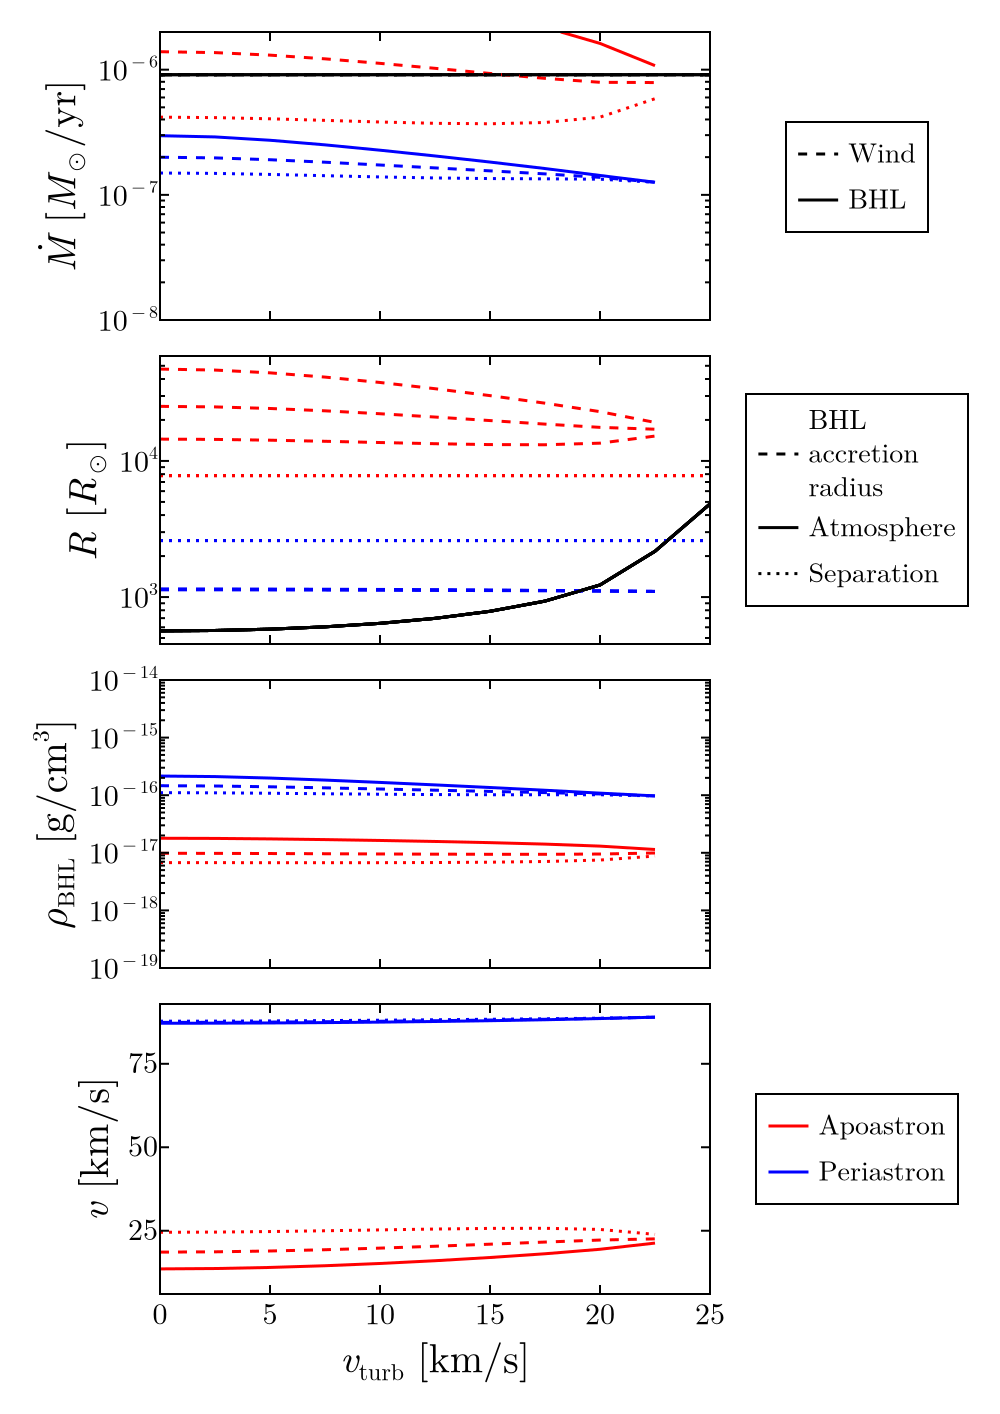

In [95]:
FIGURE = Figure(size=(500,sqrt(2)*500))
ax0 = plot_settings(FIGURE[0,1], title = "", xlabelvisible=false, xticklabelsvisible=false,
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]", yscale=log10,
                ylabel=L"\dot{M} \ [M_\odot/\mathrm{yr}]")
ax1 = plot_settings(FIGURE[1,1], title = "", xlabelvisible=false, xticklabelsvisible=false,
                ylabel=L"R \ [R_\odot]",
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]", yscale=log10)
ax2 = plot_settings(FIGURE[2,1], title = "", xlabelvisible=false, xticklabelsvisible=false,
                ylabel=L"ρ_\mathrm{BHL} \ [\mathrm{g}/\mathrm{cm}^3]",
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]", yscale=log10)
ax3 = plot_settings(FIGURE[3,1], title = "", 
                ylabel=L"v \ [\mathrm{km}/\mathrm{s}]",
                xlabel=L"v_\mathrm{turb} \ [\mathrm{km}/\mathrm{s}]")

peri_or_apo_col = Dict("peri"=>:blue, "apo"=>:red)
ls = Dict(v_infs[1] => :solid, v_infs[3] => :dash, v_infs[5] => :dot)
for v_inf in v_infs[1:2:5]
for state in ["peri", "apo"]
    lines!(ax0, v_turbs/kms, mbhls[state][v_inf]/Msun*yr, color = peri_or_apo_col[state], linestyle = ls[v_inf])
    lines!(ax0, v_turbs/kms, v_turbs .* 0. .+ abs(hs["1.000"].star_mdot[end]), color = :black, linestyle = ls[v_inf])
    lines!(ax1, v_turbs/kms, Ratms[state][v_inf]/Rsun, color = :black)
    lines!(ax1, v_turbs/kms, Ratms[state][v_inf]*0 .+ r_orbit*peri_or_apo[state]/Rsun, color = peri_or_apo_col[state], linestyle = :dot)
    lines!(ax1, v_turbs/kms, Raccs[state][v_inf]/Rsun, color = peri_or_apo_col[state], linestyle = :dash)
    lines!(ax2, v_turbs/kms, rhos[state][v_inf], color = peri_or_apo_col[state], linestyle = ls[v_inf])
    lines!(ax3, v_turbs/kms, sqrt.(v2s[state][v_inf] .^2 .+ vs[state][v_inf] .^2 .+ css[state][v_inf] .^2)/kms, color = peri_or_apo_col[state], linestyle = ls[v_inf])
end
end 

for ax in [ax0,ax1,ax2,ax3]
    xlims!(ax, 0,25)
end
lines!(ax0, [-9], [1e-6], color = :black, linestyle = :dash, label = "Wind" )
lines!(ax0, [-9], [1e-6], color = :black, linestyle = :solid, label = "BHL" )
Legend(FIGURE[0,2], ax0,  gridshalign=:center, gridsvalign=:center,nbanks=1)
lines!(ax1, [-9], [1e3], color = :black, linestyle = :dash, label = "BHL\naccretion\nradius" )
lines!(ax1, [-9], [1e3], color = :black, linestyle = :solid, label = "Atmosphere" )
lines!(ax1, [-9], [1e3], color = :black, linestyle = :dot, label = "Separation" )
Legend(FIGURE[1,2], ax1, gridshalign=:center, gridsvalign=:center,nbanks=1)
lines!(ax3, [-9], [10], color = :red, linestyle = :solid, label = "Apoastron" )
lines!(ax3, [-9], [10], color = :blue, linestyle = :solid, label = "Periastron" )
Legend(FIGURE[3,2], ax3, gridshalign=:center, gridsvalign=:center,nbanks=1)
ylims!(ax2, 1e-19,1e-14)
ylims!(ax0, 1e-8,2e-6)
save("../output/BHL.pdf", FIGURE)
FIGURE

In [94]:
end_Heburn = nothing 
ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(h, length(h.model_number) )
when = He_burn["0.50"]
    @show h.star_mass[when]    
    @show 10. ^ h.log_R[when]    
    @show  h.log_L[when]
    @show 10. ^ h.log_Teff[when]/1e3
    @show Ratms["apo"][v_infs[1]][4]/Rsun/10. ^ h.log_R[when]  

h.star_mass[when] = 11.666322892468074
10.0 ^ h.log_R[when] = 526.246034493588
h.log_L[when] = 4.532447536696244
10.0 ^ h.log_Teff[when] / 1000.0 = 3.4209512415518986
(((Ratms["apo"])[v_infs[1]])[4] / Rsun) / 10.0 ^ h.log_R[when] = 1.1482


1.1482

# KQ PUP

In [2]:
using DataFrames
cf = CSV.read("/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/Data/Models_SG/CORR_GRID_single_150.dat", DataFrame, header=1, delim = ' ', ignorerepeated=true)
using Interpolations
# import Pkg; Pkg.add("Roots")
using Roots

M_zams = []
M_50he = []
    
@printf("\n%5s (%5s) - %5s %5s %s %5s %5s %5s %5s\n", "M", "logM", "ZAMS", "TAMS", "iniHe", "He50", "endHe", "iniC", "endC")

for logm in 0.70:0.02:1.20
    @printf("Reading logm  (single stars harim)= %5.3f\r", logm)
    filename = @sprintf("%5.3f_150.data", logm)
    h  = CSV.read(POPSYNTH.SG_dir * filename, DataFrame, header=1, delim = ' ', ignorerepeated=true)

    ix_end = length(h.model_number)
    ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(h, ix_end )

    M = h.star_mass
    logms = log10(M[1])
    when = He_burn["0.50"]
    g = 10. ^ h.log_g[when]
    R = 10. ^ h.log_R[when]* Rsun
    T = 10. ^ h.log_Teff[when]
    Mdot = abs(h.star_mdot[when]) * Msun/ yr
    @printf("%13s - %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f %5.2f \n", "M" , M[ZAMS], M[TAMS], M[ini_Heburn], M[He_burn["0.50"]], M[end_Heburn], ini_Cburn > 0 ? M[ini_Cburn] : NaN, end_Cburn > 0 ? M[end_Cburn] : NaN)
    push!(M_zams, M[1])
    push!(M_50he, M[He_burn["0.50"]])
end

mass_ratio_M_heburn_M_zams =  M_50he ./ M_zams
mass_ratio_M_heburn_M_zams_function = POPSYNTH.interpolator(M_zams, mass_ratio_M_heburn_M_zams, extrapolation=:flat)


mass_ratio_M_heburn_M_zams =  M_50he ./ M_zams
he50_to_zams = POPSYNTH.interpolator(M_50he, M_zams, extrapolation=:flat)
age_postms = POPSYNTH.f_single2.age_end_BURN_H
M = 10 .^ POPSYNTH.f_single2.logM
age_postms_m = POPSYNTH.interpolator(reverse(age_postms[1:50])./1e6, reverse(M[1:50]))

f_end = POPSYNTH.f_age_CB
f_pms = POPSYNTH.f_age_pMS

function fill_betweenx!(ax, y, x_left, x_right; kwargs...)
    @assert length(y) == length(x_left) == length(x_right)
    # Construct closed polygon: (x_left, y) forward, (x_right, y) backward
    poly = [Point2f.(x_left, y); reverse(Point2f.(x_right, y))]
    return poly!(ax, poly; kwargs...)
end

# log_f_age_pMS = POPSYNTH.interpolator(log10.([0.2, 0.6, 1.0, 1.5, 2.0, 5.0, 15.0, 60.0]),
#                          log10.([200.0, 90.0, 38.9, 35.4, 23.4, 1.15, 0.117, 0.028]),
#                          extrapolation=:flat)
# age_pMS(m) = 10. .^ (log_f_age_pMS(log10.(m)))
# M_from_age_pMS(m; p0 = 5) = Roots.find_zero(x -> age_pMS(x)-m, p0)

pmsfile  = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/mist/preMS_lifetime.dat", DataFrame, header=1, delim = ' ', ignorerepeated=true)

log_ages_pms = pmsfile.logt_preMS .- 6 #Myr 
log_mass_pms = pmsfile.logMi

@show log_ages_pms
@show log_mass_pms

reverse!(log_ages_pms)
reverse!(log_mass_pms)

log_age_M_preMS = POPSYNTH.interpolator( log_ages_pms, log_mass_pms,
                         extrapolation=:flat)
# age_pMS(m) = 10. .^ (log_f_age_pMS(log10.(m)))
M_from_age_pMS2(t) = 10. .^ (log_age_M_preMS(log10.(t)))



Inv(f, x, p0) =  Roots.find_zero(xx -> f(xx)-x, p0)



    M ( logM) -  ZAMS  TAMS iniHe  He50 endHe  iniC  endC
            M -  5.01  5.00  5.00  4.98  4.97   NaN   NaN 
            M -  5.25  5.23  5.23  5.21  5.20   NaN   NaN 
            M -  5.50  5.48  5.48  5.45  5.44   NaN   NaN 
            M -  5.75  5.73  5.73  5.70  5.68   NaN   NaN 
            M -  6.03  6.00  6.00  5.96  5.94   NaN   NaN 
            M -  6.31  6.28  6.28  6.23  6.21   NaN   NaN 
            M -  6.61  6.58  6.57  6.52  6.49   NaN   NaN 
            M -  6.92  6.88  6.87  6.81  6.78   NaN   NaN 
            M -  7.24  7.20  7.19  7.11  7.07   NaN   NaN 
            M -  7.58  7.53  7.52  7.43  7.38   NaN   NaN 
            M -  7.94  7.87  7.86  7.75  7.69  7.63   NaN 
            M -  8.32  8.23  8.22  8.08  8.02  7.96   NaN 
            M -  8.71  8.60  8.58  8.42  8.34  8.28  8.28 
            M -  9.12  8.98  8.96  8.77  8.67  8.60  8.60 
            M -  9.55  9.37  9.36  9.13  9.00  8.94  8.93 
            M - 10.00  9.78  9.76  9.49  9.32  9.26  9.2

Inv (generic function with 1 method)

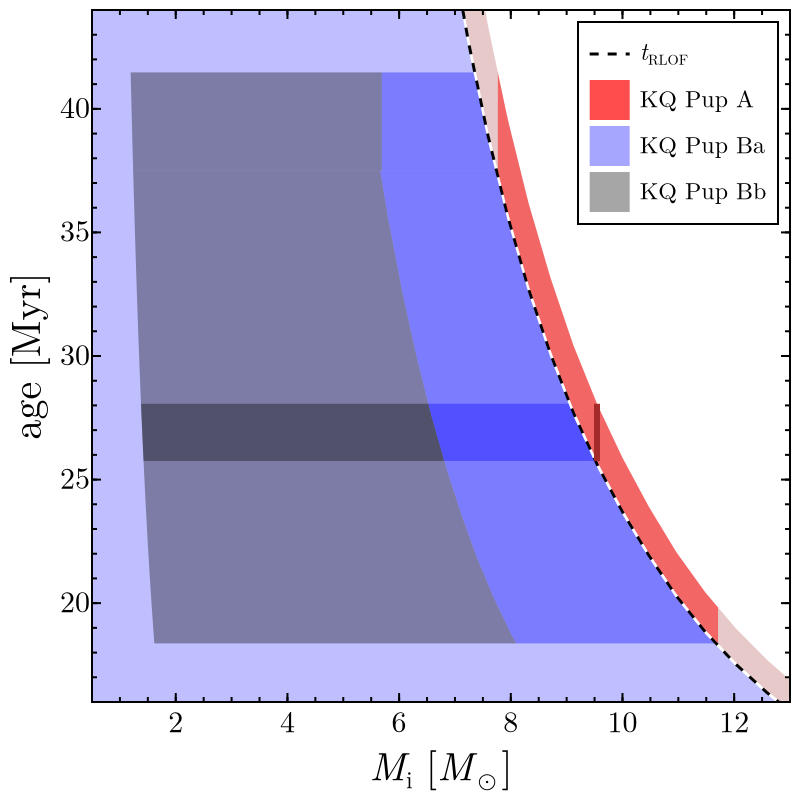

In [3]:
FIGURE = Figure(size=(400,400), figure_padding = 5)
scalex = identity
scaley = identity
ax0 = plot_settings(FIGURE[1,1], title = "", 
                xlabel=L"M_\mathrm{i} \ [M_\odot]",
                ylabel=L"\mathrm{age} \ [\mathrm{Myr}]",
                yscale=scaley, xscale=scalex,
                xticks = 0:2:100,
                xmticks = 0:0.5:100,
                yticks = 0:5:100,
                ymticks= 0:1:100)

Ms = 10. .^ cf.logM 
t_ini_BURN_He = cf.age_ini_BURN_He/1e6
t_TAMS = cf.age_end_BURN_H/1e6
t_end  = cf.age_end/1e6

fill_between!(ax0, Ms, t_ini_BURN_He, t_end, alpha = 0.5, color = :brown)
fill_between!(ax0, Ms, t_TAMS .* 0 .+ 1, t_TAMS, alpha = 0.5, color = :blue)
fill_between!(ax0, [.01,minimum(Ms)], [1,1], [100,100], alpha = 0.5, color = :blue)
lines!(ax0, Ms, (t_TAMS .+ t_ini_BURN_He) ./2, color = :black, linestyle=:dash,
            label = L"t_\mathrm{RLOF}")

            

MAmin = he50_to_zams(9.12-1.53)
MAmax = he50_to_zams(9.12+1.73) # is 12.77 halfway through He burning
MBmin = 13.68-2.30
MBmax = 13.68+2.59
MBa_min = MBmin/2
M_A_i = he50_to_zams(9.12)

x_rsg = range(MAmin, MAmax, length=100)
x_Ba0 = range(MBa_min, MAmin-.3, length = 100)
x_Ba  = range(last(x_Ba0), MAmax, length = 100)
fill_between!(ax0, x_rsg,
                   f_pms.(x_rsg)./1e6, 
                   f_end.(x_rsg)./1e6,
                    alpha = 0.7, color = :red, label = "KQ Pup A")
# fill_between!(ax0, x_Ba0, x_Ba0 .* 0 .+ f_pms(MAmax)./1e6,
#                           x_Ba0 .* 0 .+ f_end(MAmin)./1e6,
#                           alpha = 0.5, color = :blue)
# fill_between!(ax0, x_Ba, f_pms.(x_Ba)./1e6,
#                          x_Ba0 .* 0 .+ f_pms(MAmax)./1e6,
#                          alpha = 0.5, color = :blue)
lines!(ax0, [M_A_i, M_A_i], [f_pms(M_A_i)/1e6, f_end(M_A_i)/1e6], color = :brown, linestyle=:solid, linewidth=3)


ages1 = range(f_end(MAmin), f_pms(MAmin), length=100)./1e6

alpha = 0.35
fill_betweenx!(ax0, scaley.(ages1), scalex.(ages1 .* 0 .+ MBa_min),
                                   scalex.(age_postms_m.(ages1)), color = (:blue,alpha), label = "KQ Pup Ba")
fill_betweenx!(ax0, scaley.(ages1), scalex.(M_from_age_pMS2.(ages1)),
                                   scalex.(ages1 .* 0 .+ MBa_min),
                                   color = (:black,alpha), label = "KQ Pup Bb")

ages2 = range(f_pms(MAmax), f_pms(MAmin), length=100)./1e6


fill_betweenx!(ax0, scaley.(ages2), scalex.(age_postms_m.(ages2)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(age_postms_m.(ages2)) ),
                                   scalex.(age_postms_m.(ages2)), color = (:blue,alpha))
fill_betweenx!(ax0, scaley.(ages2), scalex.(M_from_age_pMS2.(ages2)),
                                   scalex.(age_postms_m.(ages2)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(age_postms_m.(ages2)) ),    
                                   color = (:black,alpha))

ages3 = range(f_pms(M_A_i)./1e6, f_end(M_A_i)./1e6, length=5)
fill_betweenx!(ax0, scaley.(ages3), scalex.(age_postms_m.(ages3)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(age_postms_m.(ages3)) ),
                                   scalex.(age_postms_m.(ages3)), color = (:blue,alpha))
fill_betweenx!(ax0, scaley.(ages3), scalex.(M_from_age_pMS2.(ages3)),
                                   scalex.(age_postms_m.(ages3)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(age_postms_m.(ages3)) ),    
                                   color = (:black,alpha))
text!(ax0, 4.,80., text="MS", color= :blue)
text!(ax0, 6.,80., text="RSG", color = :red)

axislegend(ax0, labelsize=12)



xlims!(0.5,13)
ylims!(16,44)

save("../output/KQPUP_A_Ba_Bb.pdf", FIGURE)

FIGURE

In [18]:
@show MBmax
@show MBmin
@show MBmax-9.3
@show MBmin-9.3
log10.(19660)

MBmax = 16.27
MBmin = 11.379999999999999
MBmax - 9.3 = 6.969999999999999
MBmin - 9.3 = 2.0799999999999983


4.293583513496117

In [15]:
age_min =  f_end(MAmin)
age_max =  f_pms(MAmax)

M_m = [] 
M_M = []
logL_m = []
logL_M = []
logT_m = []
logT_M = []

for logm in 0.70:0.02:1.20
    @printf("Reading logm  (single stars harim)= %5.3f\r", logm)
    filename = @sprintf("%5.3f_150.data", logm)
    h  = CSV.read(POPSYNTH.SG_dir * filename, DataFrame, header=1, delim = ' ', ignorerepeated=true)

    ix_end = length(h.model_number)
    ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(h, ix_end )
    
    age = h.star_age
    ix_m = POPSYNTH.find_nearest(age, age_min)
    ix_M = POPSYNTH.find_nearest(age, age_max)
    
    M = h.star_mass
    logL = h.log_L
    logT = h.log_Teff

    push!( M_m, M[ix_m])
    push!( M_M, M[ix_M])
    push!( logL_m, logL[ix_m])
    push!( logL_M, logL[ix_M])
    push!( logT_m, logT[ix_m])
    push!( logT_M, logT[ix_M])


end

@show age_min 
@show age_max

age_min = 4.147465242833498e7arim)= 1.200
age_max = 1.8371719806816347e7


1.8371719806816347e7

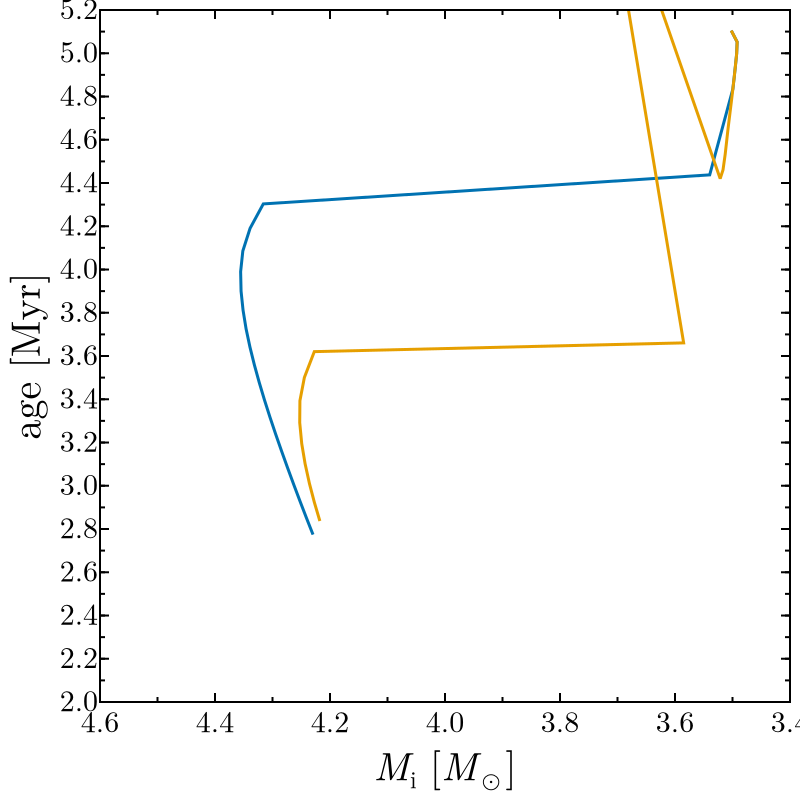

In [14]:
FIGURE = Figure(size=(400,400), figure_padding = 5)
ax0 = plot_settings(FIGURE[1,1], title = "", 
                xlabel=L"M_\mathrm{i} \ [M_\odot]",
                ylabel=L"\mathrm{age} \ [\mathrm{Myr}]",
                xticks = 0:.2:100,
                xmticks = 0:0.1:100,
                yticks = 0:.2:100,
                ymticks= 0:.1:100)

lines!(ax0, logT_M, logL_M)
lines!(ax0, logT_m, logL_m)

xlims!(ax0, 4.6, 3.4)
ylims!(ax0, 2, 5.2)
FIGURE

In [89]:
using StatsBase
# @show mean(M_from_age_pMS.(ages3, p0=0.5)) 
m_med3 = age_postms_m.(ages3)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(age_postms_m.(ages3))
@show (mean(m_med3)), maximum(m_med3), minimum(m_med3)
m_med2 = age_postms_m.(ages2)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(age_postms_m.(ages2))
@show (mean(m_med2)), maximum(m_med2), minimum(m_med2)
@show maximum(age_postms_m.(ages3))
@show M_A_i
@show maximum(age_postms_m.(ages2))
@show f_end(MAmin)/1e6
@show f_pms(MAmax)/1e6

(mean(m_med3), maximum(m_med3), minimum(m_med3)) = (6.663266159570805, 6.808426476425641, 6.5229370877627515)
(mean(m_med2), maximum(m_med2), minimum(m_med2)) = (6.648248484034884, 8.097615342440598, 5.661395377858472)
maximum(age_postms_m.(ages3)) = 9.492353524527013
M_A_i = 9.543675101661503
maximum(age_postms_m.(ages2)) = 11.641797366567364
f_end(MAmin) / 1.0e6 = 41.474652428334984
f_pms(MAmax) / 1.0e6 = 18.371719806816348


18.371719806816348

M_zams = Any[5.0119, 5.2481, 5.4954, 5.7544, 6.0256, 6.3096, 6.6069, 6.9183, 7.2444, 7.5858, 7.9433, 8.3176, 8.7096, 9.1201, 9.5499, 10.0, 10.4713, 10.9648, 11.4815, 12.0226, 12.5893, 13.1826, 13.8038, 14.4544, 15.1356, 15.8489]
M_50he = Any[4.978656, 5.208747, 5.449184, 5.699803, 5.961259, 6.234096, 6.516607, 6.809597, 7.112189, 7.425304, 7.748193, 8.081519, 8.42103, 8.770043, 9.125143, 9.486546, 9.85842, 10.26426, 10.67242, 11.08963, 11.50656, 11.92322, 12.34512, 12.75905, 13.16647, 13.56169]


26-element extrapolate(interpolate((::Vector{Any},), ::Vector{Any}, Gridded(Linear())), Flat()) with element type Float64:
  5.0119
  5.2481
  5.4954
  5.7544
  6.0256
  6.3096
  6.6069
  6.9183
  7.2444
  7.5858
  ⋮
 10.9648
 11.4815
 12.0226
 12.5893
 13.1826
 13.8038
 14.4544
 15.1356
 15.8489

In [75]:
he50_to_zams(11.5)

12.580383510421413

In [10]:
@show(MAmin)
@show(MAmax)
M_endburn_he     = POPSYNTH.interpolator(POPSYNTH.M_max_singleCC, POPSYNTH.f_single2.M_end_BURN_He,   extrapolation=:flat)
M_endburn_he     = POPSYNTH.interpolator(POPSYNTH.M_max_singleCC, POPSYNTH.f_single2.M_end_BURN_He,   extrapolation=:flat)
@show(Inv(M_endburn_he, 6.39, 6) )
@show(Inv(M_endburn_he, 6.39, 6)-6.39 )
@show(Inv(M_endburn_he, 13.77, 6) )
@show(Inv(M_endburn_he, 13.77, 6)-13.77 )
@show(15.85-13.77 )
@show(MBmin)
@show(MBmax)


MAmin = 6
MAmax = 16
Inv(M_endburn_he, 6.39, 6) = 6.500074537674401
Inv(M_endburn_he, 6.39, 6) - 6.39 = 0.11007453767440101
Inv(M_endburn_he, 13.77, 6) = 28.98186236555717
Inv(M_endburn_he, 13.77, 6) - 13.77 = 15.21186236555717
15.85 - 13.77 = 2.08
MBmin = 8.7
MBmax = 18.880000000000003


18.880000000000003

11.903816153554041:0.5223487538717828:63.616342786860535

In [13]:
fig = Figure()
ax =  Axis(fig[1,1])

min_age = f_pms(MAmax)./1e6
max_age = f_pms(MAmin)./1e6
ages = range(min_age, max_age, length=100)

Ms = 10. .^ cf.logM 
t_ini_BURN_He = cf.age_ini_BURN_He/1e6
t_TAMS = cf.age_end_BURN_H/1e6
t_end  = cf.age_end/1e6
# M_t_ini_burn_He = POPSYNTH.interpolator(reverse(t_ini_BURN_He), reverse(Ms))
rg= 1:35
M_t_TAMS = POPSYNTH.interpolator(reverse(t_TAMS[rg]), reverse(Ms[rg]))
M_t_end = POPSYNTH.interpolator(reverse(t_end[rg]), reverse(Ms[rg]))

x_left = @. M_from_age_pMS(ages, p0=0.5)
x_right = @. M_t_TAMS(ages)
y=  ages

fill_betweenx!(ax, y, x_left, x_right, color=:skyblue, strokewidth=0)
lines!(ax, x_left, y, color=:black)
lines!(ax, x_right, y, color=:black)

fig

UndefVarError: UndefVarError: `MAmax` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# MIST

In [2]:
using DataFrames
using Interpolations
using Roots

MIST_DIR = "/vol/aibn133/data1/aercolino/CATALOGUES/mist/v04_Zsun/"
@printf("\n%5s (%5s) - %8s %8s %8s %8s %8s %8s %8s\n", "M", "logM", "ZAMS", "TAMS", "iniHe", "He50", "endHe", "iniC", "endC")

M_zams = Float64[]
M_50He = Float64[]
MIST_data=Dict() 
MIST_data["age_TAMS"] = Float64[]
MIST_data["age_end"]  = Float64[]
MIST_data["age_iniHe"]= Float64[]

for m in 1:0.5:22

    filename = MIST_DIR*@sprintf("%07dM.track.eep", m*10000)
    h = CSV.read(filename, DataFrame, header=12, delim = ' ', ignorerepeated=true)
    ZAMS, H_burn, TAMS, end_Hburn, ini_Heburn, He_burn, end_Heburn, ini_Cburn, end_Cburn = POPSYNTH.evolutionary_checkpoints(h, length(h.star_age))
    ZAMS, TAMS, end_Heburn, ini_Cburn = 202, 454, 707, 808 

    M = h.star_mass 
    age = (h.star_age .- h.star_age[ZAMS])./1e6
        # @printf("%13s - %8.2f %8.2f %8.2f %8.2f %8.2f %8.2f %8.2f \n", "M" , M[ZAMS], M[TAMS], M[ini_Heburn], M[He_burn["0.50"]], M[end_Heburn], ini_Cburn > 0 ? M[ini_Cburn] : NaN, end_Cburn > 0 ? M[end_Cburn] : NaN)
    @printf("%13s - %8s %8.1f %8.1f %8.1f %8.1f %8.1f %8.1f \n", "t" , " ", age[TAMS], age[ini_Heburn], age[He_burn["0.50"]], age[end_Heburn], ini_Cburn > 0 ? age[ini_Cburn] : NaN, end_Cburn > 0 ? age[end_Cburn] : NaN)

    push!(M_zams, M[ZAMS])
    push!(M_50He, M[He_burn["0.50"]])
    push!(MIST_data["age_iniHe"],age[ini_Heburn])
    push!(MIST_data["age_TAMS"], age[TAMS])
    push!(MIST_data["age_end"],  age[ini_Cburn])
end

mass_ratio_M_heburn_M_zams =  M_50He ./ M_zams
mass_ratio_M_heburn_M_zams_function = POPSYNTH.interpolator(M_zams, mass_ratio_M_heburn_M_zams, extrapolation=:flat)
he50_to_zams = POPSYNTH.interpolator(M_50He, M_zams, extrapolation=:flat)


MIST_intp = Dict()
MIST_intp["age2M_iniHe"] = POPSYNTH.interpolator(reverse(MIST_data["age_iniHe"]), reverse(M_zams))
MIST_intp["age2M_TAMS"]  = POPSYNTH.interpolator(reverse(MIST_data["age_TAMS"]) , reverse(M_zams))
MIST_intp["age2M_end"]   = POPSYNTH.interpolator(reverse(MIST_data["age_end"])  , reverse(M_zams))
MIST_intp["M2age_iniHe"] = POPSYNTH.interpolator(M_zams, MIST_data["age_iniHe"])
MIST_intp["M2age_TAMS"]  = POPSYNTH.interpolator(M_zams, MIST_data["age_TAMS"] )
MIST_intp["M2age_end"]   = POPSYNTH.interpolator(M_zams, MIST_data["age_end"]  )

f_end = MIST_intp["M2age_end"]
f_pms = MIST_intp["M2age_iniHe"]

function fill_betweenx!(ax, y, x_left, x_right; kwargs...)
    @assert length(y) == length(x_left) == length(x_right)
    # Construct closed polygon: (x_left, y) forward, (x_right, y) backward
    poly = [Point2f.(x_left, y); reverse(Point2f.(x_right, y))]
    return poly!(ax, poly; kwargs...)
end

pmsfile  = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/mist/preMS_lifetime.dat", DataFrame, header=1, delim = ' ', ignorerepeated=true)

log_ages_pms = pmsfile.logt_preMS .- 6 #Myr 
log_mass_pms = pmsfile.logMi

reverse!(log_ages_pms)
reverse!(log_mass_pms)

log_age_M_preMS = POPSYNTH.interpolator( log_ages_pms, log_mass_pms,
                         extrapolation=:flat)
# age_pMS(m) = 10. .^ (log_f_age_pMS(log10.(m)))
M_from_age_pMS2(t) = 10. .^ (log_age_M_preMS(log10.(t)))



Inv(f, x, p0) =  Roots.find_zero(xx -> f(xx)-x, p0)



    M ( logM) -     ZAMS     TAMS    iniHe     He50    endHe     iniC     endC
            t -            9877.6  11295.5  11360.9  11405.7  11419.7      NaN 
            t -            2390.4   2777.4   2827.4   2886.2   2898.9      NaN 
            t -            1072.9   1136.3   1244.7   1323.4   1341.5      NaN 
            t -             587.9    602.3    696.4    773.8    786.9      NaN 
            t -             363.6    370.1    417.1    456.4    463.2      NaN 
            t -             245.5    249.1    273.2    296.3    299.9      NaN 
            t -             174.7    177.0    193.0    205.6    207.6      NaN 
            t -             132.7    134.1    144.0    154.6    155.8      NaN 
            t -             101.4    102.4    109.7    116.6    117.5      NaN 
            t -              81.8     82.5     88.1     93.4     94.0      NaN 
            t -              68.0     68.6     72.8     77.2     77.6      NaN 
            t -              56.3     56

Inv (generic function with 1 method)

M_A_i = 9.276900962906938


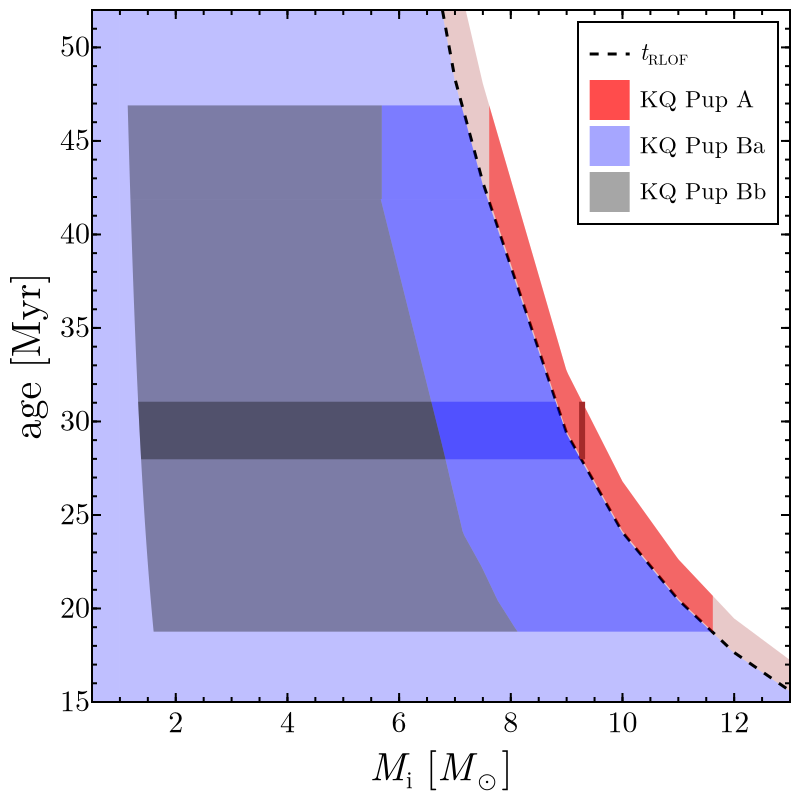

In [ ]:
FIGURE = Figure(size=(400,400), figure_padding = 5)
scalex = identity
scaley = identity
ax0 = plot_settings(FIGURE[1,1], title = "", 
                xlabel=L"M_\mathrm{i} \ [M_\odot]",
                ylabel=L"\mathrm{age} \ [\mathrm{Myr}]",
                yscale=scaley, xscale=scalex,
                xticks = 0:2:100,
                xmticks = 0:0.5:100,
                yticks = 0:5:100,
                ymticks= 0:1:100)

Ms = M_zams 
t_ini_BURN_He = MIST_intp["M2age_iniHe"].(M_zams)
t_TAMS        = MIST_intp["M2age_TAMS"].(M_zams)
t_end         = MIST_intp["M2age_end"].(M_zams)

fill_between!(ax0, Ms, t_TAMS, t_end, alpha = 0.5, color = :brown)
fill_between!(ax0, Ms, t_TAMS .* 0 .+ 1, t_TAMS, alpha = 0.5, color = :blue)
fill_between!(ax0, [.01,minimum(Ms)], [1,1], [100,100], alpha = 0.5, color = :blue)
lines!(ax0, Ms, (t_TAMS .+ t_ini_BURN_He) ./2, color = :black, linestyle=:dash,
            label = L"t_\mathrm{RLOF}")


MAmin = he50_to_zams(9.12-1.53)
MAmax = he50_to_zams(9.12+1.73) # is 12.77 halfway through He burning
MBmin = 13.68-2.30
MBmax = 13.68+2.59
MBa_min = MBmin/2
M_A_i = he50_to_zams(9.12)
@show M_A_i

x_rsg = range(MAmin, MAmax, length=100)
x_Ba0 = range(MBa_min, MAmin-.3, length = 100)
x_Ba  = range(last(x_Ba0), MAmax, length = 100)
fill_between!(ax0, x_rsg,
                   f_pms.(x_rsg), 
                   f_end.(x_rsg),
                    alpha = 0.7, color = :red, label = "KQ Pup A")
lines!(ax0, [M_A_i, M_A_i], [f_pms(M_A_i), f_end(M_A_i)], color = :brown, linestyle=:solid, linewidth=3)
ages1 = range(f_end(MAmin), f_pms(MAmin), length=100)

alpha = 0.35

fill_betweenx!(ax0, scaley.(ages1), scalex.(ages1 .* 0 .+ MBa_min),
                                    scalex.(MIST_intp["age2M_TAMS"].(ages1)), color = (:blue,alpha), label = "KQ Pup Ba")
fill_betweenx!(ax0, scaley.(ages1), scalex.(M_from_age_pMS2.(ages1)),
                                   scalex.(ages1 .* 0 .+ MBa_min),
                                   color = (:black,alpha), label = "KQ Pup Bb")

ages2 = range(f_pms(MAmax), f_pms(MAmin), length=100)


fill_betweenx!(ax0, scaley.(ages2), scalex.(MIST_intp["age2M_TAMS"].(ages2)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(MIST_intp["age2M_TAMS"].(ages2)) ),
                                   scalex.(MIST_intp["age2M_TAMS"].(ages2)), color = (:blue,alpha))
fill_betweenx!(ax0, scaley.(ages2), scalex.(M_from_age_pMS2.(ages2)),
                                   scalex.(MIST_intp["age2M_TAMS"].(ages2)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(MIST_intp["age2M_TAMS"].(ages2)) ),    
                                   color = (:black,alpha))

ages3 = range(f_pms(M_A_i), f_end(M_A_i), length=5)
fill_betweenx!(ax0, scaley.(ages3), scalex.(MIST_intp["age2M_TAMS"].(ages3)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(MIST_intp["age2M_TAMS"].(ages3)) ),
                                   scalex.(MIST_intp["age2M_TAMS"].(ages3)), color = (:blue,alpha))
fill_betweenx!(ax0, scaley.(ages3), scalex.(M_from_age_pMS2.(ages3)),
                                   scalex.(MIST_intp["age2M_TAMS"].(ages3)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(MIST_intp["age2M_TAMS"].(ages3)) ),    
                                   color = (:black,alpha))
text!(ax0, 4.,80., text="MS", color= :blue)
text!(ax0, 6.,80., text="RSG", color = :red)

axislegend(ax0, labelsize=12)

ylims!(15,52)
xlims!(0.5,13)




save("../output/KQPUP_A_Ba_Bb.pdf", FIGURE)

FIGURE

In [23]:

@show (9.12-1.53)
@show (9.12+1.73) # is 12.77 halfway through He burning

@show MAmin 
@show MAmax 
@show he50_to_zams(9.12)
@show t_max = MIST_intp["M2age_end"](MAmin)
@show t_min = MIST_intp["M2age_TAMS"](MAmax)

@show minimum(MIST_intp["age2M_TAMS"].(ages1))
@show maximum(MIST_intp["age2M_TAMS"].(ages1))
@show minimum(MIST_intp["age2M_TAMS"].(ages2))
@show maximum(MIST_intp["age2M_TAMS"].(ages2))
@show minimum(MIST_intp["age2M_TAMS"].(ages3))
@show maximum(MIST_intp["age2M_TAMS"].(ages3))


ttt2 = MIST_intp["age2M_TAMS"].(ages2)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(MIST_intp["age2M_TAMS"].(ages2))
@show maximum(ttt2)
@show minimum(ttt2)

ttt3 = MIST_intp["age2M_TAMS"].(ages3)*1.5/2 .* mass_ratio_M_heburn_M_zams_function(MIST_intp["age2M_TAMS"].(ages3))
@show maximum(ttt3)
@show minimum(ttt3)

@show MBmin 
@show MBmax 
@show MBmin - 9, MBmin - 7
@show MBmax - 9, MBmax - 7 

9.12 - 1.53 = 7.589999999999999
9.12 + 1.73 = 10.85
MAmin = 7.613105665128399
MAmax = 11.617939404558904
he50_to_zams(9.12) = 9.276900962906938
t_max = (MIST_intp["M2age_end"])(MAmin) = 46.899571257832335
t_min = (MIST_intp["M2age_TAMS"])(MAmax) = 18.687253941754996
minimum((MIST_intp["age2M_TAMS"]).(ages1)) = 7.113802194574177
maximum((MIST_intp["age2M_TAMS"]).(ages1)) = 7.583759132717982
minimum((MIST_intp["age2M_TAMS"]).(ages2)) = 7.583759132717982
maximum((MIST_intp["age2M_TAMS"]).(ages2)) = 11.591313538821503
minimum((MIST_intp["age2M_TAMS"]).(ages3)) = 8.80269718312476
maximum((MIST_intp["age2M_TAMS"]).(ages3)) = 9.250990782658608
maximum(ttt2) = 8.120931755187854
minimum(ttt2) = 5.670704723523199
maximum(ttt3) = 6.831245534328538
minimum(ttt3) = 6.57671531396625
MBmin = 11.379999999999999
MBmax = 16.27
(MBmin - 9, MBmin - 7) = (2.379999999999999, 4.379999999999999)
(MBmax - 9, MBmax - 7) = (7.27, 9.27)


(7.27, 9.27)

In [10]:
using DataFrames
dir = "/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star"
profile = CSV.read(dir * "/profCC_1.21.data", DataFrame, header=6, delim = ' ', ignorerepeated=true)


Row,zone,logT,logRho,logP,logR,luminosity,eps_grav,log_abs_eps_grav_dm_div_L,signed_log_eps_grav,net_energy,log_Ledd,log_Lrad_div_Ledd,signed_log_power,velocity,entropy,mixing_type,csound,v_div_csound,eta,mu,logdq,dq_ratio,q,log_q,radius,rmid,temperature,tau,logtau,pressure,pgas_div_ptotal,logPgas,grada,free_e,x_mass_fraction_H,y_mass_fraction_He,z_mass_fraction_metals,abar,ye,log_opacity,eps_nuc,log_abs_eps_nuc,d_lnepsnuc_dlnd,d_lnepsnuc_dlnT,non_nuc_neu,mlt_mixing_length,mlt_mixing_type,gradT_sub_grada,gradT_div_grada,log_mlt_Gamma,log_D_mix,log_D_mix_non_rotation,log_conv_vel,conv_vel_div_csound,log_mlt_D_mix,pressure_scale_height,log_D_conv,log_D_semi,log_D_ovr,log_D_thrm,gradT,gradr,gradL,mass,dq,logxq,logxm,x,y,z,neut,h1,prot,he3,he4,c12,n14,o16,ne20,mg24,si28,s32,ar36,ca40,ti44,cr48,cr56,fe52,fe54,fe56,ni56,pp,cno,tri_alfa,burn_c,burn_n,burn_o,burn_ne,burn_na,burn_mg,⋯
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,1,3.50266,-8.78541,2.51386,3.07198,1.28263e5,-2203.96,-13.2654,-3.3432,-3.3432,8.51026,-3.40216,38.6926,0.0,21.2502,6,5.38052e5,0.0,-19.7954,1.32296,-12.301,1.0,1.0,0.0,1180.26,1180.26,3181.74,0.666667,-0.176091,326.484,0.999208,2.51352,0.297179,0.0022332,0.680521,0.30393,0.0155489,1.3203,0.840216,-3.30929,2.27174e-28,-27.6436,2.27188e-28,6.79524e-29,0.0,1.24464e12,0,-0.17208,0.420955,-99.0,1.47482,-99.0,-10.1431,1.33681e-16,-99.0,11.9221,-99.0,-99.0,-99.0,-99.0,0.125099,0.125099,0.297179,12.2008,5.0e-13,-99.0,-99.0,0.680521,0.30393,0.0155489,1.01016e-99,0.680521,1.01016e-99,1.83091e-5,0.303912,0.00133007,0.00354655,0.00571144,0.00182718,0.000576716,0.000720956,0.000343479,6.26691e-5,6.64983e-5,3.77174e-69,1.01016e-99,1.01016e-99,1.01016e-99,7.81888e-5,0.00128511,1.0e-99,2.27174e-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
2,2,3.50266,-8.78541,2.51386,3.07198,1.28263e5,-2203.39,-12.8046,-3.34309,-3.34309,8.51026,-3.40216,38.6926,0.0,21.2502,6,5.38052e5,0.0,-19.7954,1.32296,-11.8401,0.345977,1.0,-2.17167e-13,1180.26,1180.26,3181.74,0.666667,-0.176091,326.484,0.999208,2.51352,0.297179,0.0022332,0.680521,0.30393,0.0155489,1.3203,0.840216,-3.30929,2.27174e-28,-27.6436,2.27188e-28,6.79524e-29,0.0,1.24464e12,0,-0.17208,0.420955,-99.0,1.47482,-99.0,-10.1431,1.33681e-16,-99.0,11.9221,-99.0,-99.0,-99.0,-99.0,0.125099,0.125099,0.297179,12.2008,1.44518e-12,-12.301,-11.2146,0.680521,0.30393,0.0155489,1.01016e-99,0.680521,1.01016e-99,1.83091e-5,0.303912,0.00133007,0.00354655,0.00571144,0.00182718,0.000576716,0.000720956,0.000343479,6.26691e-5,6.64983e-5,3.77174e-69,1.01016e-99,1.01016e-99,1.01016e-99,7.81888e-5,0.00128511,1.0e-99,2.27174e-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,⋯
3,3,3.50266,-8.78541,2.51386,3.07198,1.28263e5,-2202.97,-12.3098,-3.34301,-3.34301,8.51026,-3.40216,38.6926,0.0,21.2502,6,5.38052e5,0.0,-19.7954,1.32296,-11.3452,0.320007,1.0,-8.44799e-13,1180.26,1180.26,3181.74,0.666667,-0.176091,326.484,0.999208,2.51352,0.297179,0.0022332,0.680521,0.30393,0.0155489,1.3203,0.840216,-3.30929,2.27174e-28,-27.6436,2.27188e-28,6.79524e-29,0.0,1.24464e12,0,-0.17208,0.420955,-99.0,1.47482,-99.0,-10.1431,1.33681e-16,-99.0,11.9221,-99.0,-99.0,-99.0,-99.0,0.125099,0.125099,0.297179,12.2008,4.51609e-12,-11.711,-10.6247,0.680521,0.30393,0.0155489,1.01016e-99,0.680521,1.01016e-99,1.83091e-5,0.30391

In [19]:
h = profile.h1 
m = profile.mass
hecoremass = maximum( m[h .< 0.01] )
print(hecoremass)

ix = POPSYNTH.find_nearest(m,  5.82392)
m[ix]
h[ix]

5.823878967935291

0.009173490130129297

In [10]:
using DataFrames 

dir = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/single_stars"
dir = "/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/Data/Models_CC/single_star"

fp = open(dir * "/MRT_absoluteT.data", "w")
write(fp, @sprintf("%20s ", "Mzams"))
write(fp, @sprintf("%20s ", "ZAMS_H"))
for i in 100:-1:0
    write(fp,@sprintf("%17s%03d", "M", i))
    write(fp,@sprintf("%17s%03d", "t", i))
    write(fp,@sprintf("%17s%03d", "R", i))

end

write(fp, "\n")

for logm in union(0.00:0.10:1.00, 1.10:.02:2.00)
    fn = @sprintf("%4.2f.data", logm)
    hf = CSV.read(dir * "/" * fn, DataFrame, header=1, delim = ' ', ignorerepeated=true)
    
    M = 10 .^ logm 
    m = hf.star_mass 
    r = 10 .^ hf.log_R 
    t = hf.star_age ./ 1e6
    center_h1 = hf.center_h1
    ZAMS_h1 = center_h1[1] 
    ix0 = POPSYNTH.find_nearest(center_h1, ZAMS_h1)

    write(fp, @sprintf("%20.10f ", M))
    write(fp, @sprintf("%20.10f ", ZAMS_h1))

    for i in 100:-1:0
        H = (ZAMS_h1)*i/100

        ix = POPSYNTH.find_nearest(center_h1, H)

        write(fp,@sprintf("%20.6f", m[ix]))
        write(fp,@sprintf("%20.6f", t[ix]))
        write(fp,@sprintf("%20.6f", r[ix]))

    end
    write(fp, "\n")

    for i in 100:-1:0
    end

    for i in 100:-1:0
    end
end

close(fp)

In [6]:
dir = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/single_stars"
fff = CSV.read(dir * "/MRT.data", DataFrame, header=1, delim = ' ', ignorerepeated=true)

for i in 100:-1:0
    @printf("ix = %3d, maximum t diff = %5.3e -- ", i, maximum(diff(fff[!, "t"*@sprintf("%03d",i)])))
    @printf("maximum R diff = %5.3e\n", maximum(diff(fff[!, "R"*@sprintf("%03d",i)])))
end 
# @show diff(fff.t000)

ix = 100, maximum t diff = 1.573e+03 -- maximum R diff = 4.358e-01
ix =  99, maximum t diff = 3.683e+00 -- maximum R diff = 4.691e-01
ix =  98, maximum t diff = -1.461e+03 -- maximum R diff = 4.763e-01
ix =  97, maximum t diff = -2.157e+03 -- maximum R diff = 4.858e-01
ix =  96, maximum t diff = -4.034e+03 -- maximum R diff = 4.810e-01
ix =  95, maximum t diff = -4.784e+03 -- maximum R diff = 5.002e-01
ix =  94, maximum t diff = -6.322e+03 -- maximum R diff = 5.047e-01
ix =  93, maximum t diff = -8.580e+03 -- maximum R diff = 5.032e-01
ix =  92, maximum t diff = -8.343e+03 -- maximum R diff = 5.195e-01
ix =  91, maximum t diff = -9.466e+03 -- maximum R diff = 5.252e-01
ix =  90, maximum t diff = -1.081e+04 -- maximum R diff = 5.331e-01
ix =  89, maximum t diff = -1.227e+04 -- maximum R diff = 5.410e-01
ix =  88, maximum t diff = -1.408e+04 -- maximum R diff = 5.410e-01
ix =  87, maximum t diff = -1.420e+04 -- maximum R diff = 5.588e-01
ix =  86, maximum t diff = -1.517e+04 -- maximum R

In [15]:
100*Rsun/(1e4*kms)/60/60
km/1e5

1.0